In [ ]:
# ------------------------------------------------------------
# 경고 제거
# ------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# ============================================================
# 전자상거래 성과 분석 대시보드
# Google Colab 최종버전
# ============================================================

!apt-get -qq update
!apt-get -qq install fonts-nanum
!pip -q install openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from google.colab import files

# ============================================================
# 한글 폰트 설정
# ============================================================

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
① 아파트 매매가격지수 파일 업로드


Saving (월) 매매가격지수_아파트.xlsx to (월) 매매가격지수_아파트.xlsx

② M2 통화량 파일 업로드


Saving 광의통화(M2).xlsx to 광의통화(M2).xlsx


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")




실질 가치 상승 최고 시점
시점 : 2021-10
실질 가치 상승분 : 3.98%


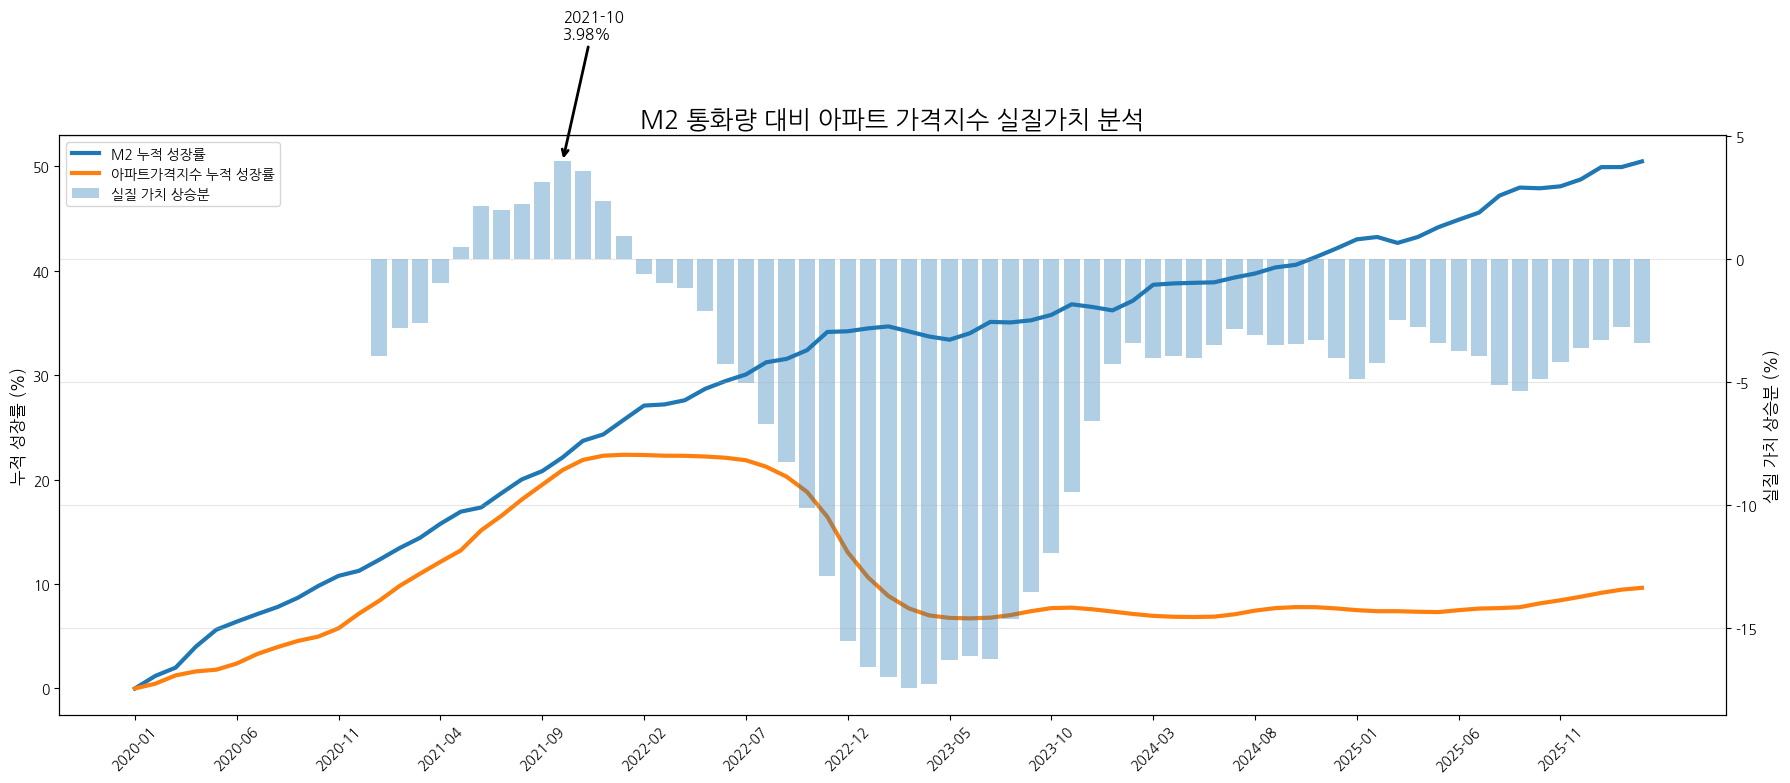

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


분석 파일 저장 완료 : M2_아파트_실질가치분석.xlsx


In [4]:
# ============================================================
# M2 통화량 vs 아파트 매매가격지수 실질가치 분석
# (2020.01 = 기준값 0%)
# Google Colab
# ============================================================

# ------------------------------------------------------------
# 한글 폰트
# ------------------------------------------------------------

!apt-get -qq update
!apt-get -qq install -y fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

# ------------------------------------------------------------
# 라이브러리
# ------------------------------------------------------------

import pandas as pd
import numpy as np

from google.colab import files
from IPython.display import display

# ============================================================
# 1. 매매가격지수 파일 업로드
# ============================================================

print("="*60)
print("① 아파트 매매가격지수 파일 업로드")
print("="*60)

uploaded = files.upload()
apt_file = list(uploaded.keys())[0]

# ============================================================
# 2. M2 파일 업로드
# ============================================================

print("\n" + "="*60)
print("② M2 통화량 파일 업로드")
print("="*60)

uploaded = files.upload()
m2_file = list(uploaded.keys())[0]

# ============================================================
# 3. 아파트 매매가격지수 읽기
# ============================================================

apt_raw = pd.read_excel(
    apt_file,
    header=None
)

# 2020-01 ~ 2026-03
months = pd.date_range(
    "2020-01-01",
    "2026-03-01",
    freq="MS"
)

apt_values = []

col = 2  # C열

for _ in range(len(months)):
    apt_values.append(
        apt_raw.iloc[3, col]
    )
    col += 2   # 증감률 열 건너뜀

apt_df = pd.DataFrame({
    "month": months.strftime("%Y-%m"),
    "apt_price": pd.to_numeric(apt_values, errors="coerce")
})

# ============================================================
# 4. M2 읽기
# ============================================================

m2_raw = pd.read_excel(
    m2_file,
    header=None
)

m2_df = pd.DataFrame({
    "month": m2_raw.iloc[7:,0].astype(str),
    "m2": pd.to_numeric(
        m2_raw.iloc[7:,1],
        errors="coerce"
    )
})

m2_df = m2_df.dropna()

m2_df["month"] = (
    pd.to_datetime(m2_df["month"])
      .dt.strftime("%Y-%m")
)

# ============================================================
# 5. 데이터 결합
# ============================================================

df = pd.merge(
    apt_df,
    m2_df,
    on="month",
    how="inner"
)

df = df.sort_values("month").reset_index(drop=True)

# ============================================================
# 6. 누적 성장률 계산
# (2020-01 = 0%)
# ============================================================

base_m2 = df.loc[0, "m2"]
base_apt = df.loc[0, "apt_price"]

df["m2_growth"] = (
    (df["m2"] / base_m2 - 1) * 100
)

df["apt_growth"] = (
    (df["apt_price"] / base_apt - 1) * 100
)

# ============================================================
# 7. 전년동월 증가율
# ============================================================

df["m2_yoy"] = (
    df["m2"].pct_change(12) * 100
)

df["apt_yoy"] = (
    df["apt_price"].pct_change(12) * 100
)

# ============================================================
# 8. 실질 가치 상승분
# 전년동월 아파트상승률 - 전년동월 M2증가율
# ============================================================

df["real_value"] = (
    df["apt_yoy"] -
    df["m2_yoy"]
)

# ============================================================
# 9. 최고 상승 시점
# ============================================================

real_df = df.dropna(subset=["real_value"])

max_idx = real_df["real_value"].idxmax()

max_month = real_df.loc[max_idx, "month"]
max_value = real_df.loc[max_idx, "real_value"]

# ============================================================
# 10. 결과 출력
# ============================================================

print("\n")
print("="*50)
print("실질 가치 상승 최고 시점")
print("="*50)
print(f"시점 : {max_month}")
print(f"실질 가치 상승분 : {max_value:.2f}%")

# ============================================================
# 11. 시각화
# ============================================================

fig, ax1 = plt.subplots(
    figsize=(18,8)
)

# ------------------------
# 성장률
# ------------------------

ax1.plot(
    df["month"],
    df["m2_growth"],
    linewidth=3,
    label="M2 누적 성장률"
)

ax1.plot(
    df["month"],
    df["apt_growth"],
    linewidth=3,
    label="아파트가격지수 누적 성장률"
)

ax1.set_ylabel("누적 성장률 (%)", fontsize=12)

# ------------------------
# 실질가치
# ------------------------

ax2 = ax1.twinx()

bars = ax2.bar(
    df["month"],
    df["real_value"],
    alpha=0.35,
    label="실질 가치 상승분"
)

ax2.set_ylabel(
    "실질 가치 상승분 (%)",
    fontsize=12
)

# ------------------------
# 최고 시점 표시
# ------------------------

peak_x = list(df["month"]).index(max_month)

ax2.annotate(
    f"{max_month}\n{max_value:.2f}%",
    xy=(peak_x, max_value),
    xytext=(peak_x, max_value + 5),
    arrowprops=dict(
        arrowstyle="->",
        lw=2
    ),
    fontsize=11,
    fontweight="bold"
)

# ------------------------
# 축 설정
# ------------------------

tick_step = max(1, len(df)//15)

ax1.set_xticks(
    range(0, len(df), tick_step)
)

ax1.set_xticklabels(
    df["month"].iloc[::tick_step],
    rotation=45
)

# ------------------------
# 범례
# ------------------------

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

plt.title(
    "M2 통화량 대비 아파트 가격지수 실질가치 분석",
    fontsize=18,
    fontweight="bold"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 12. 최종 데이터 저장
# ============================================================

output_file = "M2_아파트_실질가치분석.xlsx"

df.to_excel(
    output_file,
    index=False
)

files.download(output_file)

print("\n분석 파일 저장 완료 :", output_file)